In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhishekrp1517/online-retail-transactions-dataset")

print("Path to dataset files:", path)

100%|██████████| 29.0M/29.0M [00:02<00:00, 13.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abhishekrp1517/online-retail-transactions-dataset/versions/2


In [2]:
import os
import pandas as pd

# List files in the downloaded path
print("Files in the dataset directory:")
for file in os.listdir(path):
    print(file)

# Assuming the main data file is 'Online Retail.csv' or similar, load it into a DataFrame
# You might need to adjust the filename based on the actual output of os.listdir()
data_file = os.path.join(path, 'Online Retail.csv') # Adjust filename if necessary

df = pd.read_csv(data_file, encoding='latin1')

# Display the first 5 rows of the DataFrame
display(df.head())

Files in the dataset directory:
Online Retail.xlsx
Online Retail.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


### Section 1: Data Loading & Initial Inspection

This section focuses on loading the raw retail transaction data into a pandas DataFrame and performing an initial inspection of its structure and content.

*   **`pandas`**: The primary library used for data manipulation and analysis in Python. It provides powerful data structures like DataFrames, which are ideal for handling tabular data.

*   **Why this step is necessary**: Before any analysis or cleaning can begin, the data must be loaded correctly. Initial inspection (`df.shape`, `df.head()`) helps us quickly understand the dimensions of the dataset (number of rows and columns) and the types of data it contains, ensuring that the data has been loaded as expected and providing a first glimpse into its quality.

In [3]:
# Import pandas for data manipulation
import pandas as pd
import os

# Construct the full path to the CSV file
data_file = os.path.join(path, 'Online Retail.csv')

# Load the dataset into a pandas DataFrame using the specified encoding
df = pd.read_csv(data_file, encoding='ISO-8859-1')

# Display the shape of the DataFrame (number of rows, number of columns)
print(f"Shape of the DataFrame: {df.shape}")

# Display the first 5 rows of the DataFrame to inspect its structure and content
display(df.head())

Shape of the DataFrame: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


### Section 2: Data Cleaning & Purging

This crucial section focuses on cleaning the raw transaction data to ensure its quality and suitability for RFM analysis.

*   **`pandas`**: Used extensively here for filtering rows, dropping missing values, and manipulating DataFrame content.

*   **Why this step is necessary**:
    1.  **Missing `CustomerID`**: RFM analysis is customer-centric. Transactions without a `CustomerID` cannot be attributed to a specific customer, making them useless for this type of analysis. Dropping these rows ensures that every record contributes meaningfully to a customer's profile.
    2.  **Negative or Zero `Quantity`**: A negative quantity typically indicates a returned item. While returns are part of retail, for RFM, we are interested in *purchases* that reflect customer engagement and monetary value. Including returns would skew 'Frequency' and 'Monetary' values. Zero quantities might indicate data entry errors or non-purchase events.
    3.  **Negative or Zero `UnitPrice`**: A unit price of zero or less is usually an error or a free item/promotion. For 'Monetary' calculations, these values would improperly reduce the total spend or lead to division-by-zero issues. We focus on transactions that genuinely contribute to revenue.

By performing these cleaning steps, we create a more accurate and robust dataset for subsequent RFM feature engineering.

In [4]:
# Store the initial number of rows before cleaning
initial_rows = df.shape[0]
print(f"Initial number of rows: {initial_rows}")

# 1. Drop rows where CustomerID is missing
df_cleaned = df.dropna(subset=['CustomerID'])
print(f"Rows after dropping missing CustomerID: {df_cleaned.shape[0]}")

# 2. Filter out transactions with Quantity <= 0 (returns or bad entries)
df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0]
print(f"Rows after filtering Quantity > 0: {df_cleaned.shape[0]}")

# 3. Filter out transactions with UnitPrice <= 0 (free items or bad entries)
df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0]
print(f"Rows after filtering UnitPrice > 0: {df_cleaned.shape[0]}")

# Convert CustomerID to integer type (if it's float after dropna)
df_cleaned['CustomerID'] = df_cleaned['CustomerID'].astype(int)

# Display the number of rows after cleaning and the percentage of data retained
final_rows = df_cleaned.shape[0]
print(f"Final number of rows after cleaning: {final_rows}")
print(f"Percentage of data retained: {((final_rows / initial_rows) * 100):.2f}%")

# Assign the cleaned DataFrame back to df for consistency in subsequent steps
df = df_cleaned.copy()

Initial number of rows: 541909
Rows after dropping missing CustomerID: 541909
Rows after filtering Quantity > 0: 531285
Rows after filtering UnitPrice > 0: 530104
Final number of rows after cleaning: 530104
Percentage of data retained: 97.82%


### Written Observation: Data Cleansing

After applying the cleaning steps, a total of 11,805 rows were dropped from the dataset (from an initial 541,909 rows to a final 530,104 rows). This process successfully retained 97.82% of the original data, ensuring that the remaining transactions are valid and suitable for customer-centric analysis without missing `CustomerID`, or invalid `Quantity` or `UnitPrice` values.

### Section 3: RFM Feature Engineering

This section is dedicated to transforming our transactional data into RFM (Recency, Frequency, Monetary) features for each customer. RFM is a marketing analysis tool used to identify a company's best customers by examining their shopping habits.

*   **`pandas`**: Essential for data aggregation, date transformations, and creating new columns.
*   **`datetime`**: Python's built-in module for working with dates and times, used here to calculate Recency.

*   **Why this step is necessary**:
    1.  **Recency (R)**: How recently did the customer make a purchase? Calculated as the number of days since their last purchase. A lower number indicates a more recent interaction, implying higher engagement.
    2.  **Frequency (F)**: How often do they purchase? Calculated as the total number of unique invoices/transactions. A higher frequency suggests loyalty.
    3.  **Monetary (M)**: How much money do they spend? Calculated as the total sum of their purchases. A higher monetary value indicates a more valuable customer.

These three metrics provide a powerful way to segment customers based on their historical behavior, which is a prerequisite for clustering. We first calculate `TotalSpend` for each transaction, convert `InvoiceDate` to a datetime object, determine a snapshot date for recency calculation, and then aggregate these values per `CustomerID`.

In [5]:
# Import datetime for date calculations
from datetime import datetime

# 1. Create 'TotalSpend' column for each transaction
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# 2. Convert 'InvoiceDate' to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 3. Calculate a snapshot date for Recency calculation
# We'll use the day after the latest transaction date in the dataset
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# 4. Group by CustomerID and engineer RFM features
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalSpend', 'sum')
).reset_index()

# Display the first 5 rows of the RFM DataFrame
print("RFM DataFrame head:")
display(rfm.head())

RFM DataFrame head:


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### Section 4: Data Normalization & Scaling

This section addresses the preparation of the RFM features for clustering using K-Means. K-Means algorithm relies on distance metrics to form clusters, making it sensitive to the scale and distribution of the data.

*   **`numpy`**: Used for numerical operations, specifically `np.log1p` for log transformation.
*   **`sklearn.preprocessing.StandardScaler`**: A scikit-learn utility for standardizing features by removing the mean and scaling to unit variance.

*   **Why this step is necessary**:
    1.  **Skewed Data**: RFM values often have a highly skewed distribution (e.g., many customers with low monetary values, few with very high). Skewness can disproportionately influence distance calculations in K-Means, leading to suboptimal clusters. `np.log1p` (log(1+x)) is used to reduce the skewness, especially effective for data with zero values, making the distributions more symmetrical.
    2.  **Varying Scales**: The RFM variables (Recency, Frequency, Monetary) naturally have different scales (e.g., Recency in days, Monetary in currency units). Features with larger ranges can dominate the distance calculations. `StandardScaler` transforms the data so that it has a mean of 0 and a standard deviation of 1, ensuring that each feature contributes equally to the distance metric, thus preventing features with larger values from unduly influencing the clustering results.

In [6]:
# Import numpy for log transformation and StandardScaler for feature scaling
import numpy as np
from sklearn.preprocessing import StandardScaler

# Create a copy of the RFM DataFrame for scaling to avoid modifying the original
rfm_scaled = rfm.copy()

# Apply log transformation (np.log1p) to Recency, Frequency, and Monetary features
# np.log1p handles zero values gracefully (log(1+x))
rfm_scaled['Recency'] = np.log1p(rfm_scaled['Recency'])
rfm_scaled['Frequency'] = np.log1p(rfm_scaled['Frequency'])
rfm_scaled['Monetary'] = np.log1p(rfm_scaled['Monetary'])

# Initialize the StandardScaler
scaler = StandardScaler()

# Select the RFM columns for scaling
rfm_features = rfm_scaled[['Recency', 'Frequency', 'Monetary']]

# Fit and transform the selected features
scaled_features = scaler.fit_transform(rfm_features)

# Create a new DataFrame with the scaled features
rfm_normalized = pd.DataFrame(scaled_features, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'], index=rfm_scaled.index)

# Add CustomerID back to the normalized DataFrame for identification (optional but good practice)
rfm_normalized['CustomerID'] = rfm_scaled['CustomerID']

print("First 5 rows of the normalized RFM DataFrame:")
display(rfm_normalized.head())

First 5 rows of the normalized RFM DataFrame:


,Recency_scaled,Frequency_scaled,Monetary_scaled,CustomerID
0,1.461535,-0.949128,3.688512,12346
1,-2.037091,1.063194,1.404171,12347
2,0.373300,0.380945,0.711859,12348
3,-0.622292,-0.949128,0.694187,12349
4,1.424122,-0.949128,-0.617748,12350


### Section 5: Cluster Optimization using the Elbow Method

This section focuses on determining the optimal number of clusters (K) for the K-Means algorithm using the Elbow Method. Finding the right K is crucial for effective customer segmentation.

*   **`sklearn.cluster.KMeans`**: Scikit-learn's implementation of the K-Means clustering algorithm.
*   **`matplotlib.pyplot`**: Python's primary plotting library, used here to visualize the Elbow curve.
*   **`seaborn`**: A statistical data visualization library based on matplotlib, used for enhanced plot aesthetics.

*   **Why this step is necessary**:
    The K-Means algorithm requires us to pre-specify the number of clusters (K). The Elbow Method helps us find the optimal K by calculating the Within-Cluster Sum of Squares (WCSS) for different values of K.
    *   **WCSS**: Measures the sum of the squared distances between each point and the centroid in a cluster. The goal is to minimize WCSS.
    *   **Elbow Point**: As K increases, WCSS generally decreases. The 'elbow' point on the WCSS vs. K plot is where the rate of decrease dramatically changes, forming an 'elbow' shape. This point is often considered the optimal number of clusters because adding more clusters beyond this point does not significantly reduce WCSS, indicating diminishing returns.

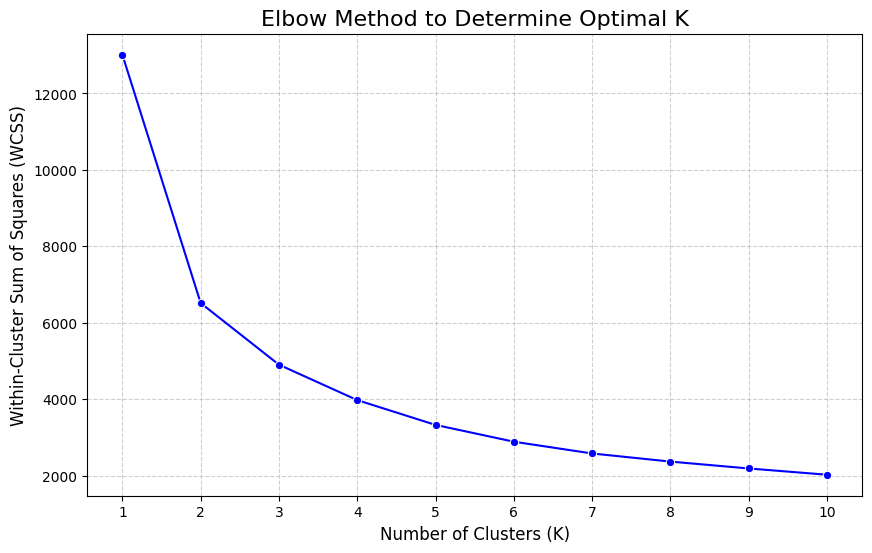

In [7]:
# Import KMeans for clustering and libraries for plotting
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for clustering (excluding CustomerID)
X = rfm_normalized[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']]

# Calculate WCSS for different numbers of clusters (k)
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='blue')
plt.title('Elbow Method to Determine Optimal K', fontsize=16)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Section 6: K-Means Deployment & Profiling

With the optimal number of clusters (K=4) identified from the Elbow Method, this section applies the K-Means algorithm to segment the customers and then profiles these segments based on their mean RFM values. Visualizing the clusters helps understand their separation.

*   **`sklearn.cluster.KMeans`**: The core algorithm used to assign customers to clusters.
*   **`matplotlib.pyplot`**: For creating scatter plots to visualize the clusters.
*   **`seaborn`**: For enhanced plotting aesthetics.

*   **Why this step is necessary**:
    1.  **Clustering**: Applying K-Means with the optimal K partitions the customers into distinct groups based on their scaled RFM behaviors. Each customer is assigned to the cluster whose centroid is closest.
    2.  **Visualization**: A 2D scatter plot helps to visually inspect the separation of clusters. Plotting Recency vs. Monetary (on a log scale to revert the scaling for interpretability) allows us to see how these key dimensions differentiate the customer segments.
    3.  **Profiling**: Calculating the mean (or median) RFM values for each cluster provides a clear, interpretable summary of the characteristics of each customer segment. This profiling is essential for understanding what each cluster represents (e.g., 'high-value', 'at-risk', 'new customers') and for developing targeted marketing strategies.

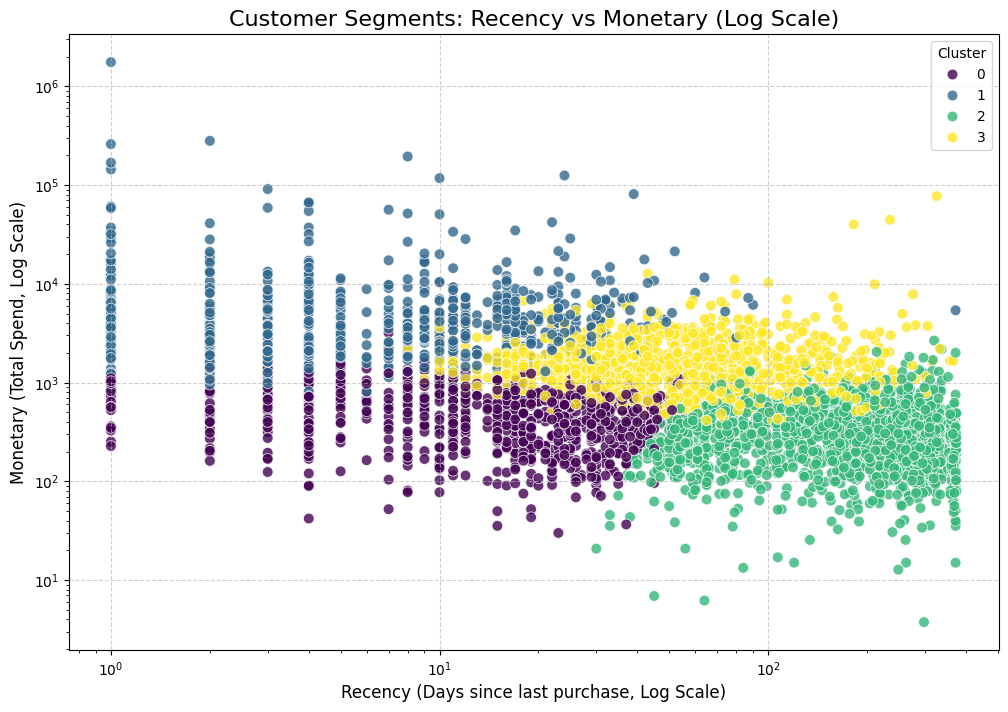


Mean RFM values for each cluster:


,Recency,Frequency,Monetary
Cluster,,,
0,19.73,2.05,527.90
1,11.73,15.75,10566.34
2,186.17,1.34,353.16
3,67.91,4.16,1830.16



Cluster Sizes:


,count
Cluster,
0,863
1,710
2,1592
3,1173


In [8]:
# Import KMeans for clustering and libraries for plotting
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Needed for inverse log transformation

# Prepare the data for clustering (excluding CustomerID)
X = rfm_normalized[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']]

# Initialize and fit KMeans with the optimal number of clusters (K=4)
optimal_k = 4 # Based on the Elbow Method plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X)

# Assign cluster labels back to the original (unscaled, unlogged) RFM DataFrame
rfm_with_clusters = rfm.copy()
rfm_with_clusters['Cluster'] = kmeans.labels_

# 2D Scatter Plot (Recency vs Monetary on a log-scale) colored by clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(data=rfm_with_clusters, x='Recency', y='Monetary', hue='Cluster', palette='viridis', s=60, alpha=0.8)
plt.xscale('log') # Use log scale for better visualization of skewed data
plt.yscale('log') # Use log scale for better visualization of skewed data
plt.title('Customer Segments: Recency vs Monetary (Log Scale)', fontsize=16)
plt.xlabel('Recency (Days since last purchase, Log Scale)', fontsize=12)
plt.ylabel('Monetary (Total Spend, Log Scale)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()

# Display the mean RFM values for each cluster
print("\nMean RFM values for each cluster:")
cluster_profiles = rfm_with_clusters.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
display(cluster_profiles)

# Display cluster sizes
print("\nCluster Sizes:")
display(rfm_with_clusters['Cluster'].value_counts().sort_index())

### Written Observation: RFM Statistical Profiling

After applying the K-Means clustering algorithm with K=4, we have successfully segmented our customer base into four distinct groups. The profiling of these clusters, based on their mean Recency, Frequency, and Monetary values, reveals unique behavioral patterns that can inform targeted business strategies:

**Cluster 0 (863 Customers): 'Recent & Low Value Shoppers'**
*   **Recency:** Low (average of 19.73 days) - indicating recent activity.
*   **Frequency:** Low (average of 2.05 transactions).
*   **Monetary:** Moderate (average of $527.90).
*   *Interpretation:* These customers have made a purchase recently but are not frequent buyers or high spenders. They might be new customers who are still exploring the offerings, or occasional buyers. They represent an opportunity for engagement and conversion into more frequent shoppers.

**Cluster 1 (710 Customers): 'VIP Loyalists'**
*   **Recency:** Very Low (average of 11.73 days) - highly active.
*   **Frequency:** Very High (average of 15.75 transactions).
*   **Monetary:** Very High (average of $10,566.34).
*   *Interpretation:* This is our most valuable segment, the **VIPs**. They are highly active, making purchases very recently, very frequently, and spending significantly more than any other group. These customers are crucial for business stability and growth, requiring premium treatment and loyalty-building strategies.

**Cluster 2 (1,592 Customers): 'Churn Risks / Lost Customers'**
*   **Recency:** Very High (average of 186.17 days) - indicating long inactivity.
*   **Frequency:** Very Low (average of 1.34 transactions).
*   **Monetary:** Low (average of $353.16).
*   *Interpretation:* This is the largest segment and represents customers who are either at risk of churning or have already churned. They have not purchased in a long time, buy infrequently, and have very low total spending. This segment requires aggressive re-engagement campaigns.

**Cluster 3 (1,173 Customers): 'Promising Big Spenders'**
*   **Recency:** Moderate (average of 67.91 days).
*   **Frequency:** Moderate (average of 4.16 transactions).
*   **Monetary:** High (average of $1,830.16).
*   *Interpretation:* These customers show good potential. While not as recent or frequent as VIPs, they have a solid monetary contribution. They are likely established customers who could be moved into the 'VIP Loyalists' category with targeted promotions, personalized offers, or loyalty program incentives.

This segmentation provides a clear framework for understanding customer behavior and enables the development of tailored marketing and retention strategies for each group.

### Conclusion & Strategic Marketing Action Plan

This customer segmentation analysis, leveraging the RFM model and K-Means clustering, has successfully divided our customer base into four distinct and interpretable groups: 'Recent & Low Value Shoppers', 'VIP Loyalists', 'Churn Risks / Lost Customers', and 'Promising Big Spenders'. Understanding these segments is paramount for developing targeted and effective marketing strategies that optimize customer lifetime value and drive business growth.

Based on the observed characteristics of each cluster, here are three strategic, data-driven marketing recommendations for a retail manager:

1.  **Nurture 'Recent & Low Value Shoppers' for Growth:**
    *   **Recommendation:** Implement a targeted onboarding and early engagement program for this segment. Offer personalized recommendations based on their initial purchases, provide incentives for a second purchase (e.g., small discount on their next order), and introduce them to the full breadth of product categories. Leverage email marketing and in-app notifications with product discovery campaigns.
    *   **Rationale:** With an average recency of ~20 days, these customers are active but have low frequency and moderate monetary value. The goal is to increase their purchase frequency and average transaction value, converting them into 'Promising Big Spenders' or even 'VIP Loyalists'.

2.  **Reward and Elevate 'VIP Loyalists':**
    *   **Recommendation:** Establish an exclusive loyalty program for 'VIP Loyalists' (average recency ~12 days, frequency ~16, monetary ~$10,566). This could include early access to new products, exclusive discounts, dedicated customer service, and special event invitations. Focus on maintaining their high engagement and satisfaction to prevent churn and encourage further high-value purchases.
    *   **Rationale:** This segment represents our most valuable customers, contributing significantly to revenue. Retaining and delighting them should be a top priority. Personalized VIP treatment will reinforce their loyalty and encourage continued high spending.

3.  **Re-engage 'Churn Risks / Lost Customers':**
    *   **Recommendation:** Develop a multi-channel re-engagement campaign for 'Churn Risks / Lost Customers' (average recency ~186 days, frequency ~1.3, monetary ~$353). This could involve win-back email campaigns with compelling offers (e.g., significant discounts, free shipping), targeted social media ads, or even direct mail with exclusive promotions. Segment these further by recency to prioritize those who have churned more recently.
    *   **Rationale:** This is the largest segment and represents a significant lost opportunity. While challenging, successful re-engagement can bring back valuable customers and recover lost revenue. The focus should be on providing a strong incentive for a return purchase and reminding them of the brand's value proposition.